Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Dataset loaded successfully.
Shape: (120000, 3)
   Class Index                                              Title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4            3  Oil prices soar to all-time record, posing new...   

                                         Description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  

Columns after formatting: ['Category', 'Text']
Category
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64

Preprocessing text... this can take a few minutes.


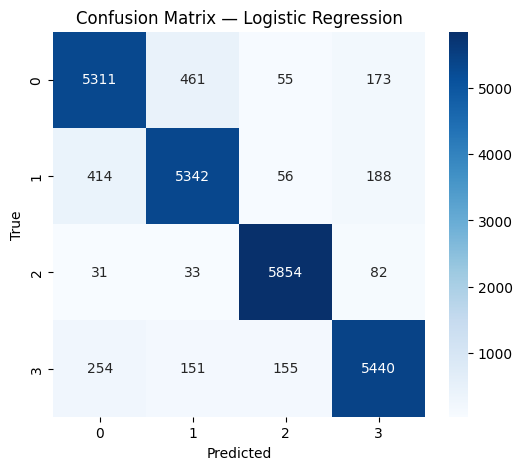

In [2]:
# ============================================================
# 📰 AG News Text Classification — Fixed and Complete Version
# ============================================================

# --- 1. Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

# --- 2. Imports ---
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

# --- 3. Download NLTK Resources ---
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# --- 4. Load Dataset ---
file_path = '/content/drive/MyDrive/Datasets/train.csv'
df = pd.read_csv(file_path)
print("Dataset loaded successfully.")
print("Shape:", df.shape)
print(df.head())

# --- 5. Normalize Columns ---
# Many AG News CSVs have ['Class Index', 'Title', 'Description']
if 'Class Index' in df.columns:
    df['Category'] = df['Class Index'].map({
        1: 'World',
        2: 'Sports',
        3: 'Business',
        4: 'Sci/Tech'
    })
    df['Text'] = df['Title'].astype(str) + " " + df['Description'].astype(str)
    df = df[['Category', 'Text']]

print("\nColumns after formatting:", df.columns.tolist())
print(df['Category'].value_counts())

# --- 6. Preprocess Text ---
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

print("\nPreprocessing text... this can take a few minutes.")
df['Clean_Text'] = df['Text'].apply(preprocess_text)

# Drop empty or NaN rows
df = df[df['Clean_Text'].notna() & (df['Clean_Text'].str.strip() != "")]
df = df[df['Category'].notna()]

# --- 7. Remove rare labels (< 2 samples) ---
label_counts = df['Category'].value_counts()
df = df[df['Category'].isin(label_counts[label_counts > 1].index)]

print(f"Rows before cleaning: {len(label_counts)} categories -> after cleaning: {len(df)} rows")
print("Category distribution after cleaning:\n", df['Category'].value_counts())

# --- 8. Split Dataset ---
X = df['Clean_Text']
y = df['Category']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

# --- 9. TF-IDF Vectorization ---
vectorizer = TfidfVectorizer(max_features=10000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# --- 10. Logistic Regression Model ---
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_tfidf, y_train)
y_pred = model_lr.predict(X_test_tfidf)

print("\n=== Logistic Regression Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- 11. Confusion Matrix Visualization ---
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
